In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

import sys  
sys.path.insert(1, '../python_files/')
import qubits
import pulses

In [2]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

### Transmonin määrittely

In [3]:
E_C = 0.3*2*np.pi #Varausenergia (GHz)
E_J = 8*2*np.pi #Josephsonin energia (GHz)

qubit=qubits.Transmon(E_C,E_J,500)

In [4]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11]-qubit.energies[0])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[  0.          25.48860139  48.57030326  69.5813038   82.4548144
 109.4189376  110.44497738 160.29841201 160.30648659 227.12458838
 227.12460681]


In [5]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "Times", "Nimbus Roman"]
plt.rcParams["font.size"] = 21

plt.rcParams["mathtext.fontset"] = "stix"

## Simulaatio

In [6]:
f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän kulmataajuus

dim = 7

evolution_eigenbasis=qubits.time_evolution(qubit.H_D_eigbasis(dim))

### Simulaatio alkuperäiselle pulssille

In [7]:
def sim_pulse(f_d,A,evolution,dim,f_rabi,K=20):
    T_floquet = 2*np.pi/(f_d) #Floquet-jakson pituus
    dt = T_floquet/K #Diskretoidaan aika-avaruus siten, että Floquet-jakson pituus on K aikapistettä

    N_pulse=int(1/(f_rabi*dt)) #Määritellään pulssin pituus arvatun Rabi-taajuuden perusteella

    #Kokonainen pulssi rampin aikakehityksen sekä Floquet-operaattorin laskemista varten
    pulse = pulses.Pulse(f_d,f_ef,[pulses.one],[N_pulse],time_unit=dt,offset_input=0)
    U_floquet=evolution.U_floquet(A*pulse.raw[0:K],dt)
    
    #Simuloitujen pulssien määrä, jaetaan kahdellakymmenellä koska jokainen simulaatio edistää tilaa yhden Floquet-jakson (20dt)
    N_sim=int(N_pulse/K)+1

    #Lopulliset todennäköisyydet eripituisten pulssien jälkeen
    last_vals=[]

    psi = np.zeros(dim, dtype=complex) #Alustetaan kubitin tila perustilaan
    psi[0] = 1
    
    #Simulaatio pulsseille
    for i in range(0,N_sim):
        psi = U_floquet @ psi #Kehitetään kubitin tilaa yhdellä Floquet-jaksolla
        last_vals.append(psi)

    #e- ja f-tasojen lopulliset todennäköisyydet
    e_vals = np.array([np.abs(a[1])**2 for a in last_vals])
    f_vals = np.array([np.abs(a[2])**2 for a in last_vals])

    #e-tason suurin todennäköisyys
    excited_max=max(e_vals)
    #f-tason suurin todennäköisyys pulssille, jolla e-taso saavuttaa suurimman arvonsa
    f_max=max(f_vals)

    #Pulssin pituus määritettynä maksimiarvon sijainnin perusteella
    T_pulse = np.argmax(e_vals)*K*dt

    #Simuloitujen pulssien pituudet, plottausta varten
    pulse_times=np.arange(0,N_sim)*K*dt
    
    return (excited_max,f_max,T_pulse,last_vals,pulse_times)

def find_params(q,A,evolution,f_rabi,AC_stark):

    #Rajat AC-stark siirtymälle
    min_range = -400
    max_range = 400

    f_d = q.frequency/3 #Ajotaajuus
    
    #Arvot eri ajotaajuuksille/AC-stark siirtymille
    pulse_times=[]
    max_e_vals=[]
    max_f_vals=[]
    AC_stark_vals=[]
    
    for i in range(min_range,max_range):
        delta=AC_stark+i/10000 #AC-stark siirtymä
        AC_stark_vals.append(delta)

        sim_vals = sim_pulse(f_d+delta,A,evolution,dim,f_rabi)
            
        max_e_vals.append(sim_vals[0])
        max_f_vals.append(sim_vals[1])
        pulse_times.append(sim_vals[2])

    plt.figure()
    plt.plot(AC_stark_vals, max_e_vals)
    print(AC_stark_vals)
    print("-----")
    print(max_e_vals)
    plt.xlabel("$\delta$ (GHz)")
    plt.ylabel("Maximum population of the e-state")
    
    ax = plt.gca()
    
    ax.text(0.02, 0.98, "(b)",
        transform=ax.transAxes,
        va="top",
        fontweight="bold",
        fontsize=16)
    
    plt.show()
    
    index=np.argmax(max_e_vals)
    AC_stark=AC_stark_vals[index]
    e_max=max_e_vals[index]
    f_max=max_f_vals[index]
    pi_pulse=pulse_times[index]
    
    return(AC_stark,pi_pulse,[e_max,f_max],max_e_vals)

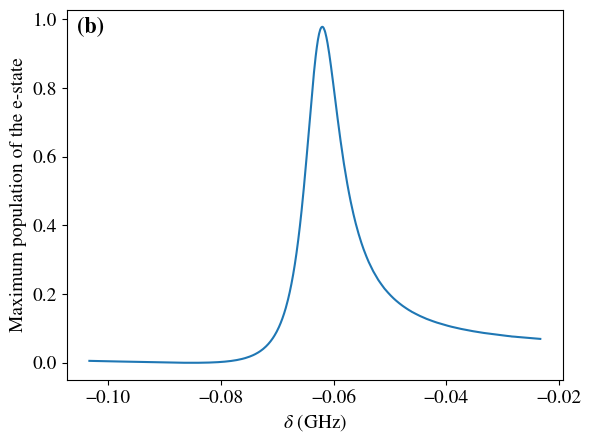

'else:\n        vals=sim_pulse_NF(f_d_opt,A,evolution_eigenbasis,dim,f_rabi/m)\n        freqs = np.fft.rfftfreq(len(vals[4]), d=vals[4][1]-vals[4][0]) '

Amplitudi (GHz): 5.6074923056918955
AC-stark siirtymä (GHz): -0.06196869591671427
E-tason suurin todennäköisyys: 0.9782095009316996
Pulssin pituus (ns): 263.71667984955667
Rabi-taajuus (fourier):  0.0018754674743472353


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pulse duration (ns)')

Text(0, 0.5, 'Probability')

Text(0.02, 0.92, '(b)')

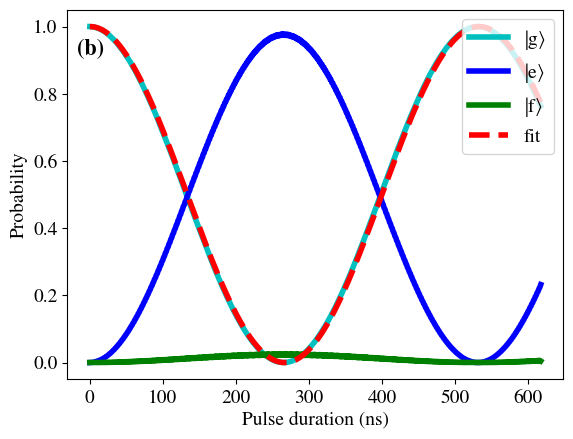

---------------------------------------------


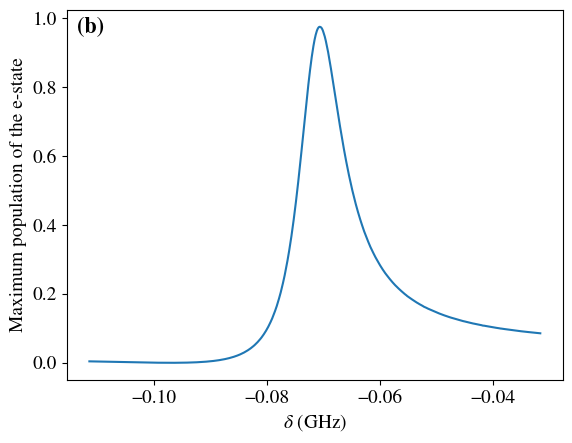

'else:\n        vals=sim_pulse_NF(f_d_opt,A,evolution_eigenbasis,dim,f_rabi/m)\n        freqs = np.fft.rfftfreq(len(vals[4]), d=vals[4][1]-vals[4][0]) '

Amplitudi (GHz): 5.983113799853076
AC-stark siirtymä (GHz): -0.07064694066194885
E-tason suurin todennäköisyys: 0.9750969807999461
Pulssin pituus (ns): 219.24452504825143
Rabi-taajuus (fourier):  0.0022782773397321053


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pulse duration (ns)')

Text(0, 0.5, 'Probability')

Text(0.02, 0.92, '(b)')

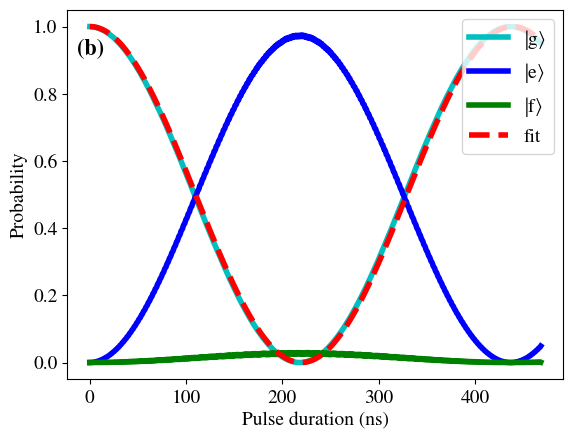

---------------------------------------------


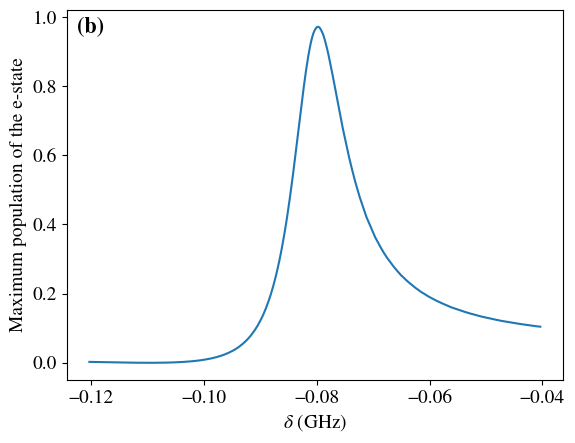

'else:\n        vals=sim_pulse_NF(f_d_opt,A,evolution_eigenbasis,dim,f_rabi/m)\n        freqs = np.fft.rfftfreq(len(vals[4]), d=vals[4][1]-vals[4][0]) '

Amplitudi (GHz): 6.358735294014255
AC-stark siirtymä (GHz): -0.07978097873114248
E-tason suurin todennäköisyys: 0.9718193803838451
Pulssin pituus (ns): 179.91589675752974
Rabi-taajuus (fourier):  0.002754827400526749


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pulse duration (ns)')

Text(0, 0.5, 'Probability')

Text(0.02, 0.92, '(b)')

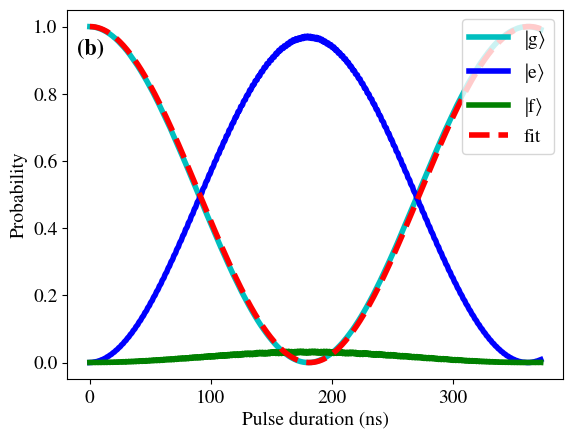

---------------------------------------------


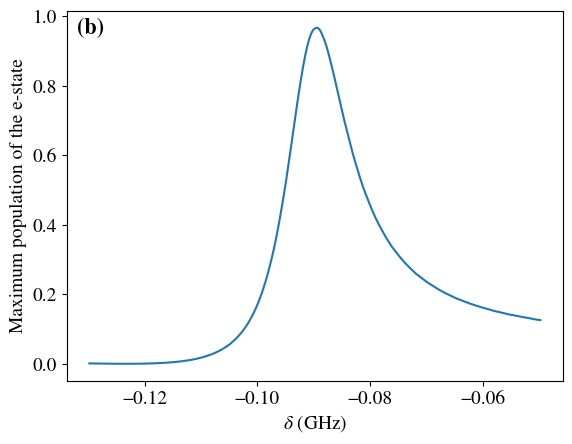

'else:\n        vals=sim_pulse_NF(f_d_opt,A,evolution_eigenbasis,dim,f_rabi/m)\n        freqs = np.fft.rfftfreq(len(vals[4]), d=vals[4][1]-vals[4][0]) '

Amplitudi (GHz): 6.734356788175434
AC-stark siirtymä (GHz): -0.0894708101242952
E-tason suurin todennäköisyys: 0.9681230080264164
Pulssin pituus (ns): 148.73249500485733
Rabi-taajuus (fourier):  0.003294534851320295


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pulse duration (ns)')

Text(0, 0.5, 'Probability')

Text(0.02, 0.92, '(b)')

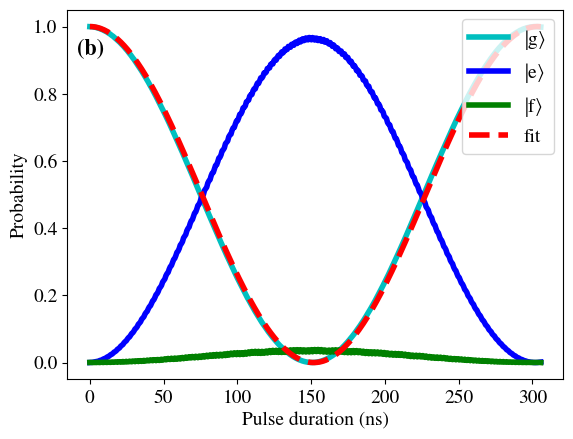

---------------------------------------------


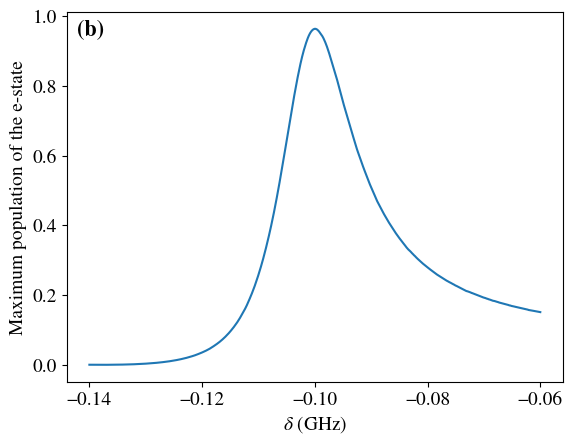

'else:\n        vals=sim_pulse_NF(f_d_opt,A,evolution_eigenbasis,dim,f_rabi/m)\n        freqs = np.fft.rfftfreq(len(vals[4]), d=vals[4][1]-vals[4][0]) '

Amplitudi (GHz): 7.1099782823366136
AC-stark siirtymä (GHz): -0.09991643484140698
E-tason suurin todennäköisyys: 0.9643840637167895
Pulssin pituus (ns): 127.9643094376893
Rabi-taajuus (fourier):  0.003900496516964254


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pulse duration (ns)')

Text(0, 0.5, 'Probability')

Text(0.02, 0.92, '(b)')

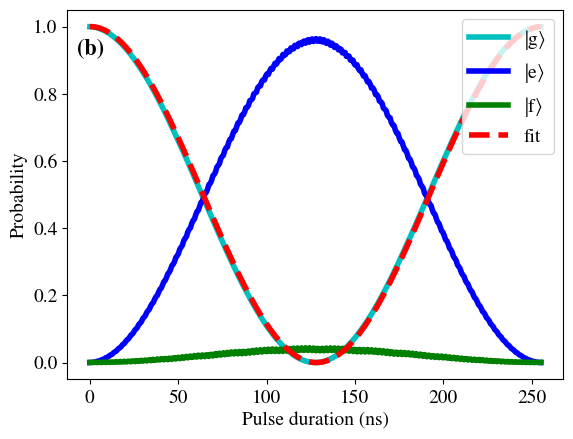

---------------------------------------------


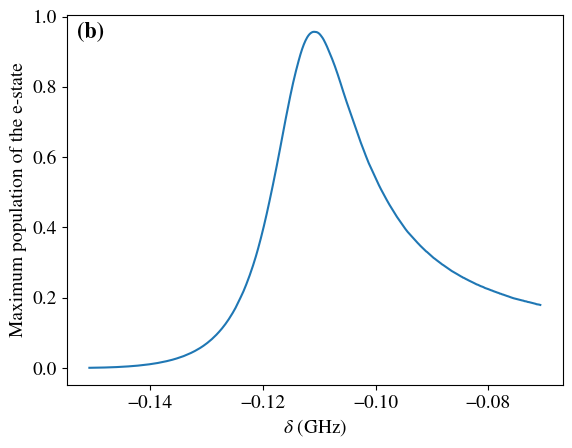

'else:\n        vals=sim_pulse_NF(f_d_opt,A,evolution_eigenbasis,dim,f_rabi/m)\n        freqs = np.fft.rfftfreq(len(vals[4]), d=vals[4][1]-vals[4][0]) '

Amplitudi (GHz): 7.485599776497793
AC-stark siirtymä (GHz): -0.11091785288247785
E-tason suurin todennäköisyys: 0.9597352149248135
Pulssin pituus (ns): 108.650108992552
Rabi-taajuus (fourier):  0.004553396694524399


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pulse duration (ns)')

Text(0, 0.5, 'Probability')

Text(0.02, 0.92, '(b)')

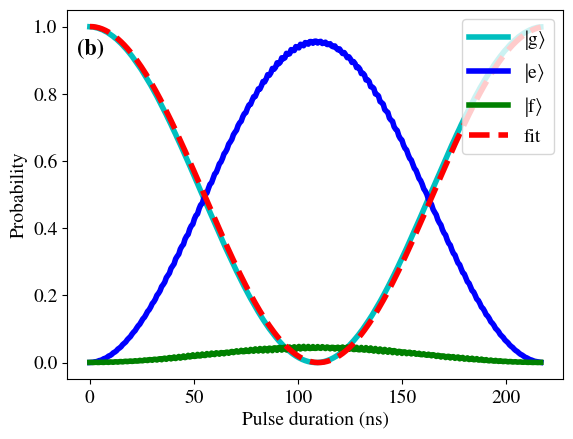

---------------------------------------------


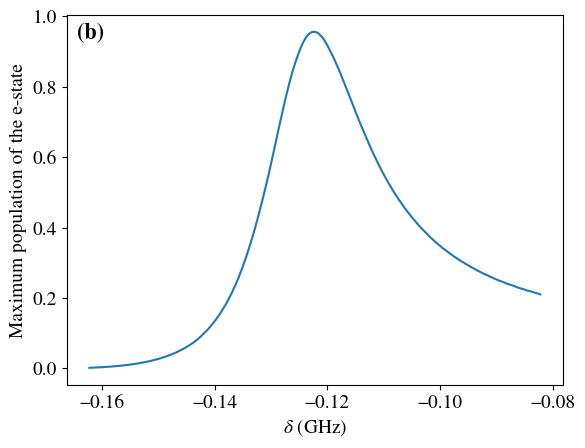

'else:\n        vals=sim_pulse_NF(f_d_opt,A,evolution_eigenbasis,dim,f_rabi/m)\n        freqs = np.fft.rfftfreq(len(vals[4]), d=vals[4][1]-vals[4][0]) '

Amplitudi (GHz): 7.861221270658973
AC-stark siirtymä (GHz): -0.12247506424750781
E-tason suurin todennäköisyys: 0.9558648315804539
Pulssin pituus (ns): 93.7931596728207
Rabi-taajuus (fourier):  0.005313917561880334


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pulse duration (ns)')

Text(0, 0.5, 'Probability')

Text(0.02, 0.92, '(b)')

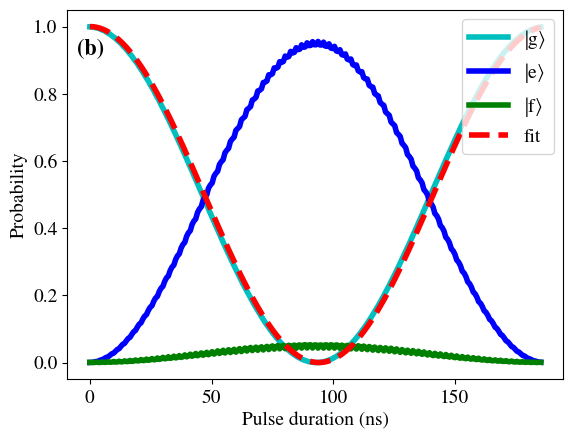

---------------------------------------------


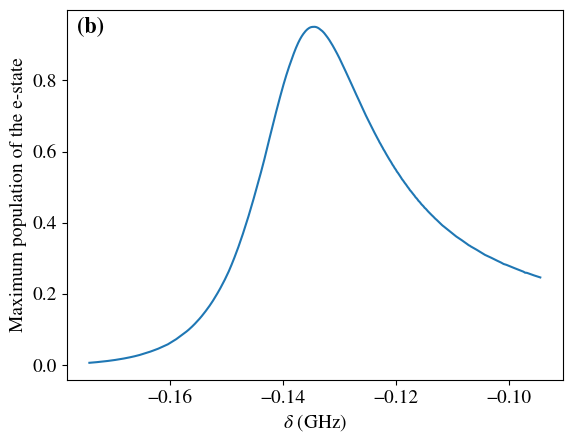

'else:\n        vals=sim_pulse_NF(f_d_opt,A,evolution_eigenbasis,dim,f_rabi/m)\n        freqs = np.fft.rfftfreq(len(vals[4]), d=vals[4][1]-vals[4][0]) '

Amplitudi (GHz): 8.236842764820153
AC-stark siirtymä (GHz): -0.13448806893649687
E-tason suurin todennäköisyys: 0.9512734335176339
Pulssin pituus (ns): 78.89944381594209
Rabi-taajuus (fourier):  0.006214372450408386


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pulse duration (ns)')

Text(0, 0.5, 'Probability')

Text(0.02, 0.92, '(b)')

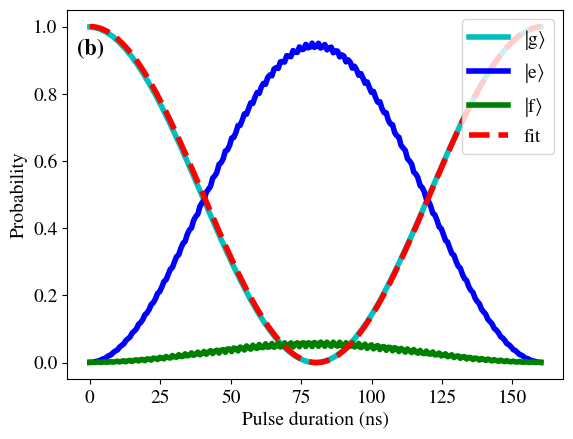

---------------------------------------------


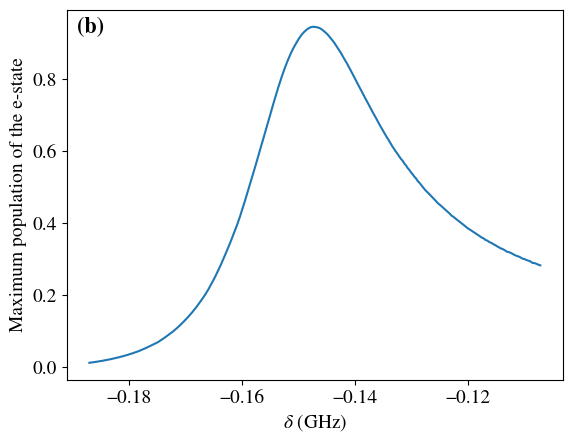

'else:\n        vals=sim_pulse_NF(f_d_opt,A,evolution_eigenbasis,dim,f_rabi/m)\n        freqs = np.fft.rfftfreq(len(vals[4]), d=vals[4][1]-vals[4][0]) '

Amplitudi (GHz): 8.612464258981332
AC-stark siirtymä (GHz): -0.14735686694944491
E-tason suurin todennäköisyys: 0.9464763621715854
Pulssin pituus (ns): 70.74266179118288
Rabi-taajuus (fourier):  0.007077758152185239


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pulse duration (ns)')

Text(0, 0.5, 'Probability')

Text(0.02, 0.92, '(b)')

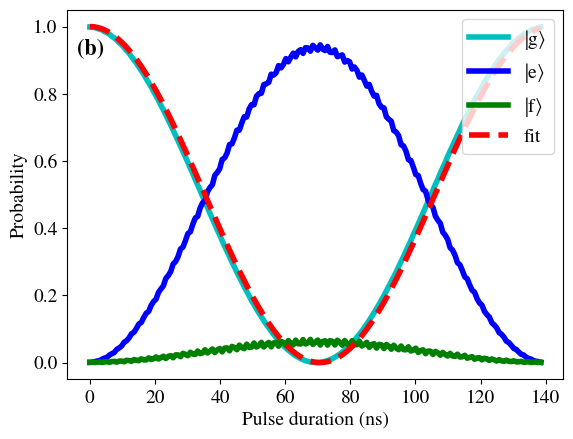

---------------------------------------------


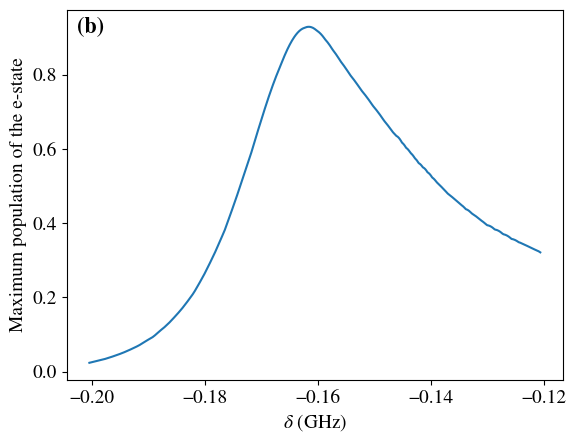

'else:\n        vals=sim_pulse_NF(f_d_opt,A,evolution_eigenbasis,dim,f_rabi/m)\n        freqs = np.fft.rfftfreq(len(vals[4]), d=vals[4][1]-vals[4][0]) '

Amplitudi (GHz): 8.988085753142512
AC-stark siirtymä (GHz): -0.16158145828635212
E-tason suurin todennäköisyys: 0.9356364980187912
Pulssin pituus (ns): 61.06314032871375
Rabi-taajuus (fourier):  0.00801705764506023


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pulse duration (ns)')

Text(0, 0.5, 'Probability')

Text(0.02, 0.92, '(b)')

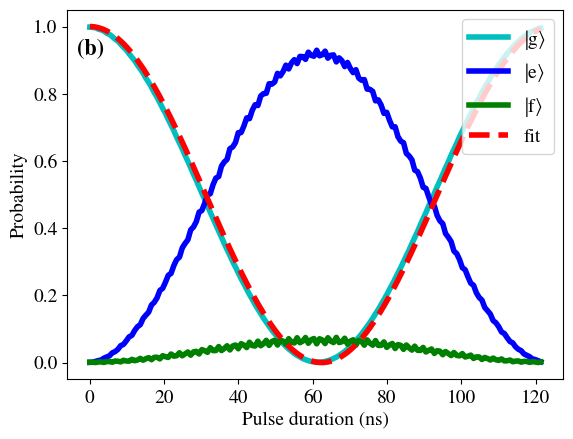

---------------------------------------------


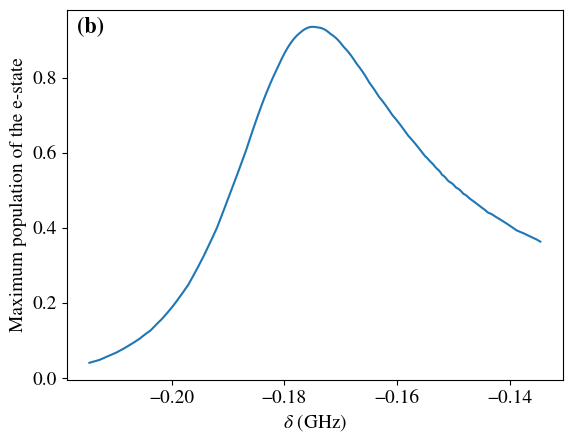

'else:\n        vals=sim_pulse_NF(f_d_opt,A,evolution_eigenbasis,dim,f_rabi/m)\n        freqs = np.fft.rfftfreq(len(vals[4]), d=vals[4][1]-vals[4][0]) '

Amplitudi (GHz): 9.363707247303692
AC-stark siirtymä (GHz): -0.17496184294721842
E-tason suurin todennäköisyys: 0.9362421811497282
Pulssin pituus (ns): 53.61054731991714
Rabi-taajuus (fourier):  0.009224812470731087


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pulse duration (ns)')

Text(0, 0.5, 'Probability')

Text(0.02, 0.92, '(b)')

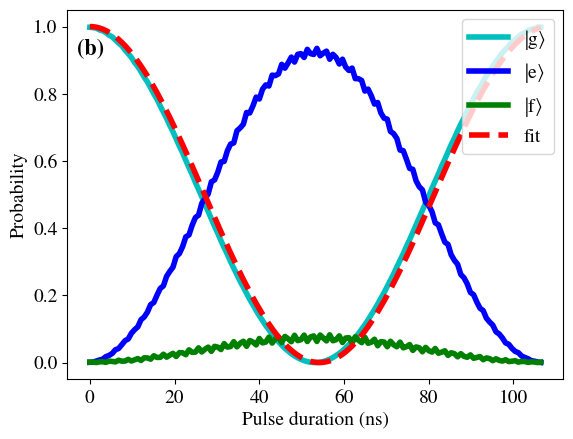

---------------------------------------------


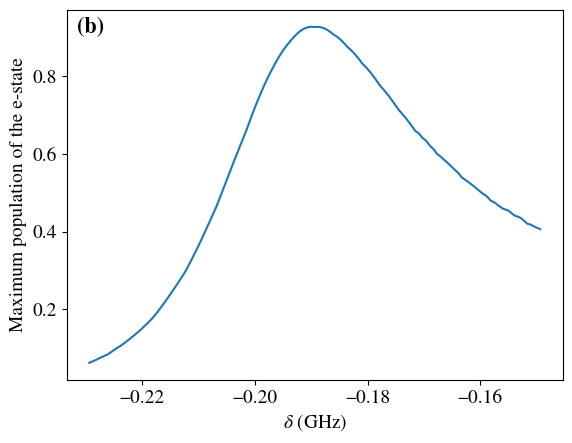

'else:\n        vals=sim_pulse_NF(f_d_opt,A,evolution_eigenbasis,dim,f_rabi/m)\n        freqs = np.fft.rfftfreq(len(vals[4]), d=vals[4][1]-vals[4][0]) '

Amplitudi (GHz): 9.73932874146487
AC-stark siirtymä (GHz): -0.1898980209320437
E-tason suurin todennäköisyys: 0.9304078683444847
Pulssin pituus (ns): 48.411897165542186
Rabi-taajuus (fourier):  0.010465130350019159


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pulse duration (ns)')

Text(0, 0.5, 'Probability')

Text(0.02, 0.92, '(b)')

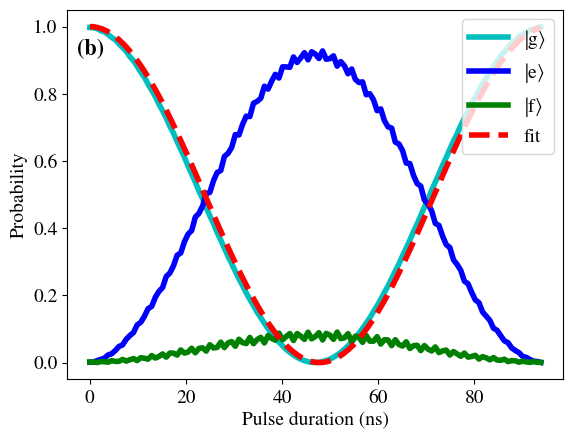

---------------------------------------------


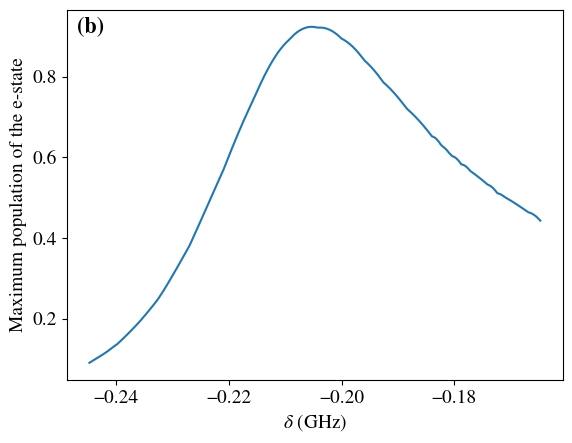

'else:\n        vals=sim_pulse_NF(f_d_opt,A,evolution_eigenbasis,dim,f_rabi/m)\n        freqs = np.fft.rfftfreq(len(vals[4]), d=vals[4][1]-vals[4][0]) '

Amplitudi (GHz): 10.11495023562605
AC-stark siirtymä (GHz): -0.20528999224082808
E-tason suurin todennäköisyys: 0.9242042373321255
Pulssin pituus (ns): 41.68121138282748
Rabi-taajuus (fourier):  0.011828540296440163


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pulse duration (ns)')

Text(0, 0.5, 'Probability')

Text(0.02, 0.92, '(b)')

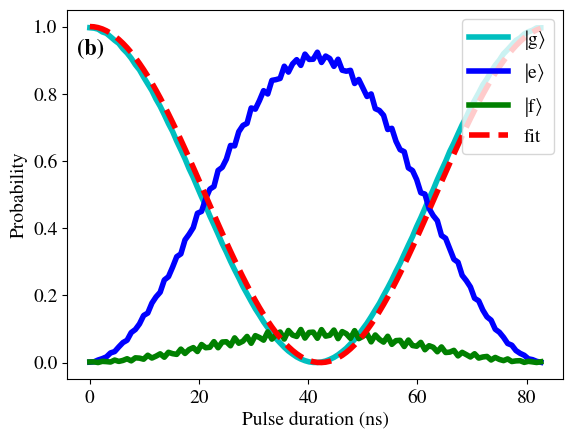

---------------------------------------------


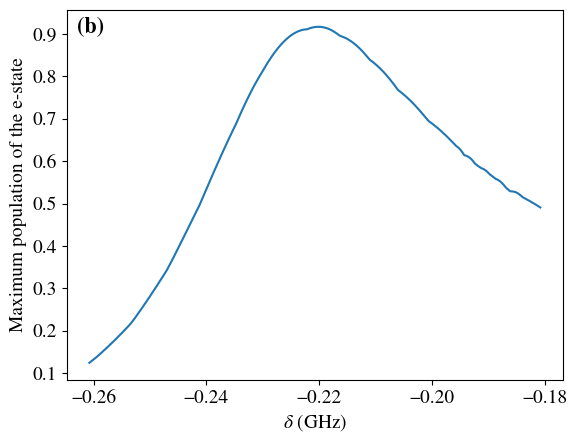

'else:\n        vals=sim_pulse_NF(f_d_opt,A,evolution_eigenbasis,dim,f_rabi/m)\n        freqs = np.fft.rfftfreq(len(vals[4]), d=vals[4][1]-vals[4][0]) '

Amplitudi (GHz): 10.49057172978723
AC-stark siirtymä (GHz): -0.2201377568735716
E-tason suurin todennäköisyys: 0.9187382320540451
Pulssin pituus (ns): 34.923191665812986
Rabi-taajuus (fourier):  0.01359301166788543


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pulse duration (ns)')

Text(0, 0.5, 'Probability')

Text(0.02, 0.92, '(b)')

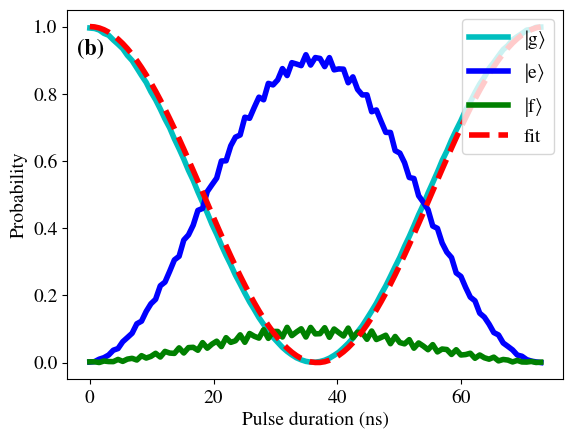

---------------------------------------------


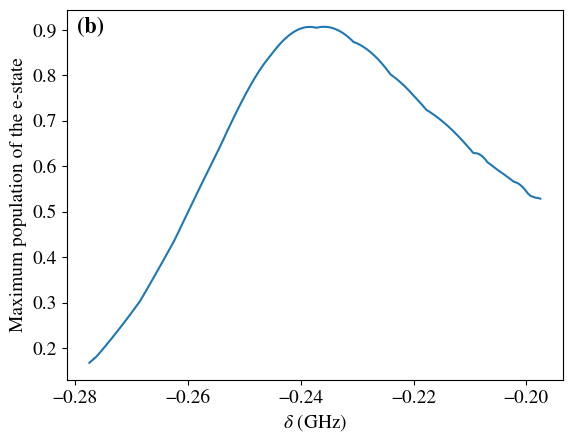

'else:\n        vals=sim_pulse_NF(f_d_opt,A,evolution_eigenbasis,dim,f_rabi/m)\n        freqs = np.fft.rfftfreq(len(vals[4]), d=vals[4][1]-vals[4][0]) '

Amplitudi (GHz): 10.86619322394841
AC-stark siirtymä (GHz): -0.23584131483027412
E-tason suurin todennäköisyys: 0.9111004359628426
Pulssin pituus (ns): 30.42572456885395
Rabi-taajuus (fourier):  0.01541345436754027


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pulse duration (ns)')

Text(0, 0.5, 'Probability')

Text(0.02, 0.92, '(b)')

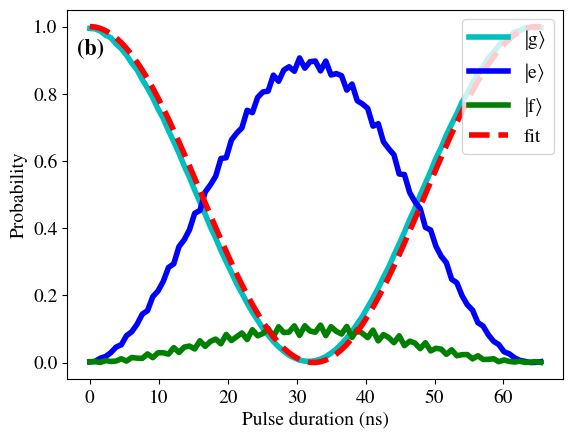

---------------------------------------------


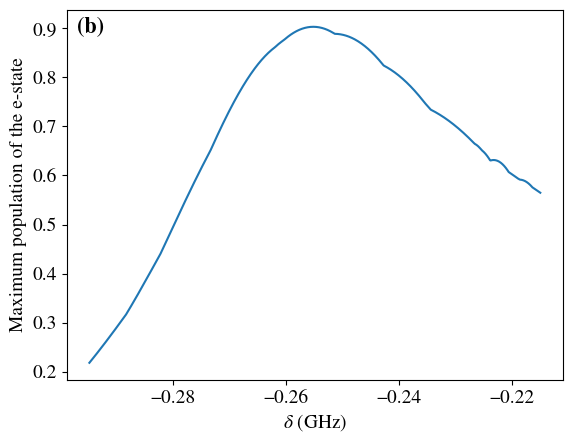

'else:\n        vals=sim_pulse_NF(f_d_opt,A,evolution_eigenbasis,dim,f_rabi/m)\n        freqs = np.fft.rfftfreq(len(vals[4]), d=vals[4][1]-vals[4][0]) '

Amplitudi (GHz): 11.24181471810959
AC-stark siirtymä (GHz): -0.25510066611093585
E-tason suurin todennäköisyys: 0.9067004648509016
Pulssin pituus (ns): 28.209566937730845
Rabi-taajuus (fourier):  0.016915292355113385


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pulse duration (ns)')

Text(0, 0.5, 'Probability')

Text(0.02, 0.92, '(b)')

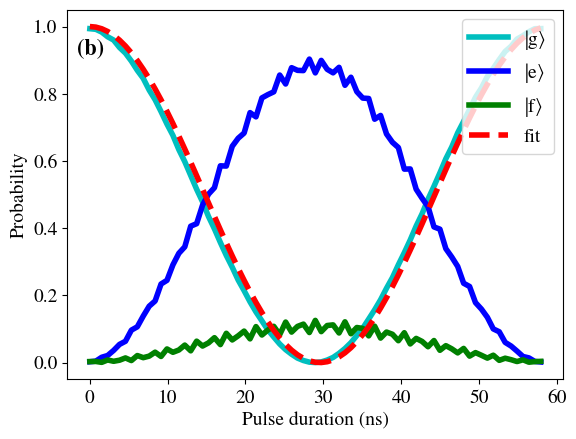

---------------------------------------------


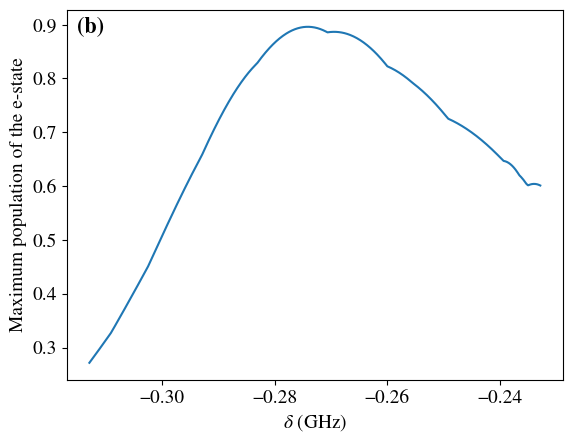

'else:\n        vals=sim_pulse_NF(f_d_opt,A,evolution_eigenbasis,dim,f_rabi/m)\n        freqs = np.fft.rfftfreq(len(vals[4]), d=vals[4][1]-vals[4][0]) '

Amplitudi (GHz): 11.61743621227077
AC-stark siirtymä (GHz): -0.27411581071555663
E-tason suurin todennäköisyys: 0.8996121865953285
Pulssin pituus (ns): 25.982255045299972
Rabi-taajuus (fourier):  0.018691380187685458


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pulse duration (ns)')

Text(0, 0.5, 'Probability')

Text(0.02, 0.92, '(b)')

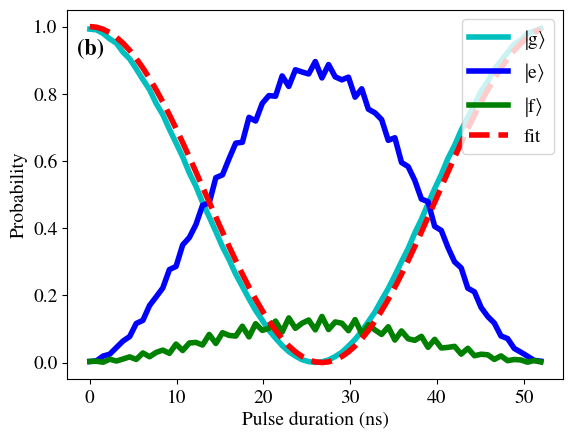

---------------------------------------------


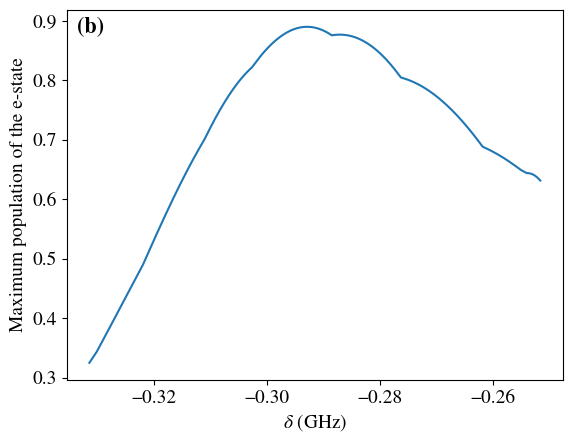

'else:\n        vals=sim_pulse_NF(f_d_opt,A,evolution_eigenbasis,dim,f_rabi/m)\n        freqs = np.fft.rfftfreq(len(vals[4]), d=vals[4][1]-vals[4][0]) '

Amplitudi (GHz): 11.99305770643195
AC-stark siirtymä (GHz): -0.2928867486441364
E-tason suurin todennäköisyys: 0.8930608340488427
Pulssin pituus (ns): 23.74391024174503
Rabi-taajuus (fourier):  0.02080717881722879


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pulse duration (ns)')

Text(0, 0.5, 'Probability')

Text(0.02, 0.92, '(b)')

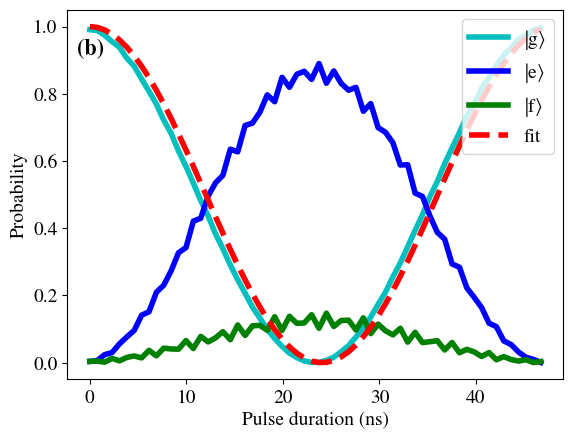

---------------------------------------------


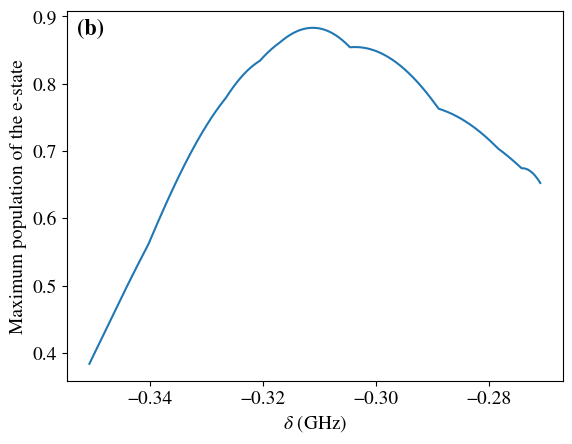

'else:\n        vals=sim_pulse_NF(f_d_opt,A,evolution_eigenbasis,dim,f_rabi/m)\n        freqs = np.fft.rfftfreq(len(vals[4]), d=vals[4][1]-vals[4][0]) '

Amplitudi (GHz): 12.368679200593128
AC-stark siirtymä (GHz): -0.3112134798966752
E-tason suurin todennäköisyys: 0.8870474647193257
Pulssin pituus (ns): 21.49413175128607
Rabi-taajuus (fourier):  0.023328816932856315


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pulse duration (ns)')

Text(0, 0.5, 'Probability')

Text(0.02, 0.92, '(b)')

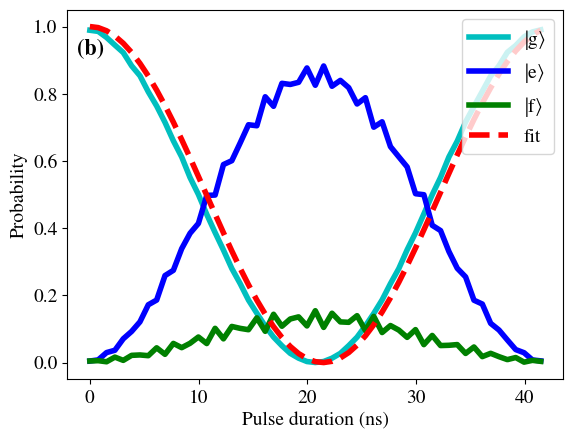

---------------------------------------------


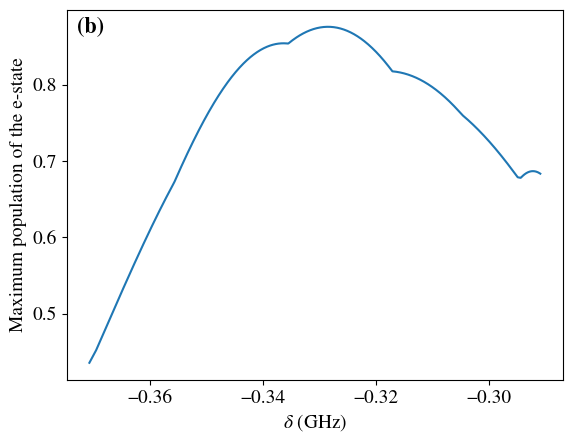

'else:\n        vals=sim_pulse_NF(f_d_opt,A,evolution_eigenbasis,dim,f_rabi/m)\n        freqs = np.fft.rfftfreq(len(vals[4]), d=vals[4][1]-vals[4][0]) '

Amplitudi (GHz): 12.744300694754308
AC-stark siirtymä (GHz): -0.32849600447317323
E-tason suurin todennäköisyys: 0.8791087054851933
Pulssin pituus (ns): 17.69325307935983
Rabi-taajuus (fourier):  0.026349943344227834


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Pulse duration (ns)')

Text(0, 0.5, 'Probability')

Text(0.02, 0.92, '(b)')

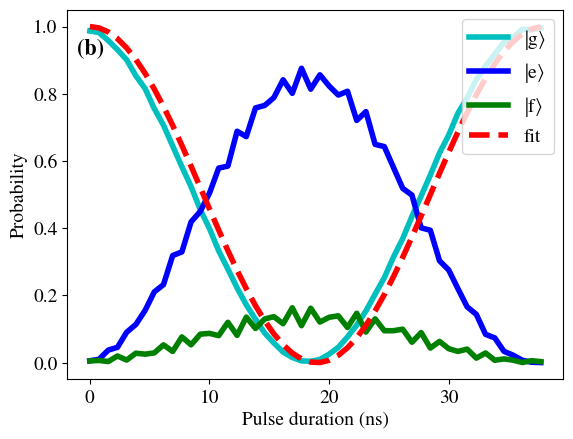

---------------------------------------------


In [8]:
deltas = [] #AC Stark siirtymät
pulse_lengths = [] #Pulssin pituudet
max_vals = [] #Suurimmat tasojen todennäköisyydet
rabis = [] #Rabi taajuudet (fouriermuunnoksesta)
data = [] #e-tason suurimmat todennäköisyydet amplitudin ja AC-stark siirtymän suhteen
A_vals = [] #Ajavan amplitudin arvot

#Määritellään rajat amplitudille sekä simulaatioiden määrä
min_range = 0.22
max_range = 0.50
N_data=20
d_data=(max_range-min_range)/(N_data-1)

for i in range (0,N_data):
    
    A = qubit.frequency*(min_range+i*d_data)
    A_vals.append(A)

    f_rabi=2.875e-05*A**3 - 0.0003995*A**2 + 0.003097*A - 0.008257 #Arvaus Rabi-taajuudelle
    AC_stark=-0.002324*A**2 + 0.005164 *A - 0.01915 #Arvaus AC-stark siirtymälle
    params=find_params(qubit, A, evolution_eigenbasis,f_rabi,AC_stark)
    deltas.append(params[0])
    pulse_lengths.append(params[1])
    data.append(params[3])
    max_vals.append(params[2])
    
    f_d_opt = qubit.frequency/3+deltas[-1] #Löydetty optimaalinen ajotaajuus

    m=100
    T_floquet = 2*np.pi/(f_d_opt)

    vals=sim_pulse(f_d_opt,A,evolution_eigenbasis,dim,f_rabi/m)
    freqs = np.fft.rfftfreq(len(vals[4]), d=T_floquet) 
    """else:
        vals=sim_pulse_NF(f_d_opt,A,evolution_eigenbasis,dim,f_rabi/m)
        freqs = np.fft.rfftfreq(len(vals[4]), d=vals[4][1]-vals[4][0]) """

    print("Amplitudi (GHz):", A)
    print("AC-stark siirtymä (GHz):", deltas[-1])

    print("E-tason suurin todennäköisyys:", vals[0])
    print("Pulssin pituus (ns):", pulse_lengths[-1])
    
    g_vals=np.array([np.abs(arr[0])**2 for arr in vals[3]])
    e_vals=np.array([np.abs(arr[1])**2 for arr in vals[3]])
    f_vals=np.array([np.abs(arr[2])**2 for arr in vals[3]])

    g_vals_offset = g_vals-0.5 #Siirretään g-tason todennäköisyyksiä puolella alaspäin, dc-komponentin minimoinniksi
    fft_vals = np.fft.rfft(g_vals_offset) #Fourier-muunnos

    magnitude = np.abs(fft_vals) #Taajuuskomponentit
    magnitude[0] = 0 #Hylätään nollataajuus/vakiokomponentti

    frequency=freqs[np.argmax(magnitude)] #Suurin g-tason aikakehityksen taajuuskomponentti=Rabi-taajuus
    print("Rabi-taajuus (fourier): ",frequency)
    rabis.append(frequency)

    n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä
    
    plot_vals= 0.5*(1+np.cos(2*np.pi*frequency*vals[4][:n_picked])) #Sovite Rabi-taajuudella

    plt.figure()
    plt.plot(vals[4][:n_picked], g_vals[:n_picked], linewidth=4, color='c')
    plt.plot(vals[4][:n_picked], e_vals[:n_picked], linewidth=4, color='b')
    plt.plot(vals[4][:n_picked], f_vals[:n_picked], linewidth=4, color='g')
    plt.plot(vals[4][:n_picked], plot_vals, ls='--', linewidth=4, color='r')
    plt.xlabel("Pulse duration (ns)")
    plt.ylabel("Probability")
    plt.legend(
        [r"|$\mathrm{g}\rangle$", r"|$\mathrm{e}\rangle$", r"|$\mathrm{f}\rangle$", "fit"],
        loc="upper right"
    )
    #print(vals[4][:n_picked])
    #print(g_vals[:n_picked])
    #print(f_vals[:n_picked])
    #print(e_vals[:n_picked])
    
    ax = plt.gca()

    ax.text(0.02, 0.92, "(b)",
        transform=ax.transAxes,
        va="top",
        fontweight="bold",
        fontsize=16)
    #plt.title("Tasojen suurimmat todennäköisyydet")
    if i==0:
        plt.savefig("resonanssi-sub.pdf")   
    plt.show()

    print("---------------------------------------------")

[np.float64(5.6074923056918955), np.float64(5.983113799853076), np.float64(6.358735294014255), np.float64(6.734356788175434), np.float64(7.1099782823366136), np.float64(7.485599776497793), np.float64(7.861221270658973), np.float64(8.236842764820153), np.float64(8.612464258981332), np.float64(8.988085753142512), np.float64(9.363707247303692), np.float64(9.73932874146487), np.float64(10.11495023562605), np.float64(10.49057172978723), np.float64(10.86619322394841), np.float64(11.24181471810959), np.float64(11.61743621227077), np.float64(11.99305770643195), np.float64(12.368679200593128), np.float64(12.744300694754308)]


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Amplitudi (GHz)')

Text(0, 0.5, 'delta=ω_d-ω_q/3 (GHz)')

Text(0.5, 1.0, 'AC stark siirtymä')

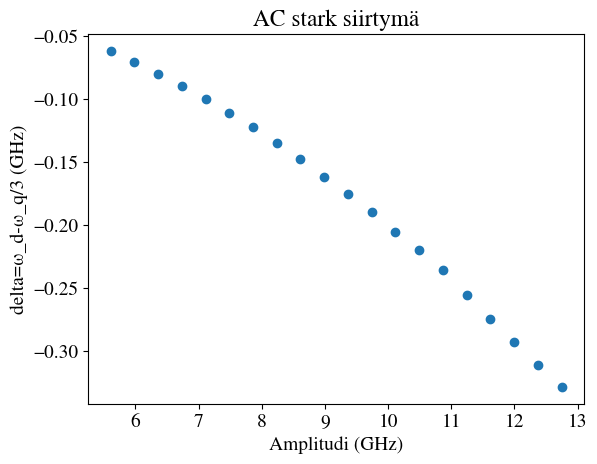

[np.float64(-0.06196869591671427), np.float64(-0.07064694066194885), np.float64(-0.07978097873114248), np.float64(-0.0894708101242952), np.float64(-0.09991643484140698), np.float64(-0.11091785288247785), np.float64(-0.12247506424750781), np.float64(-0.13448806893649687), np.float64(-0.14735686694944491), np.float64(-0.16158145828635212), np.float64(-0.17496184294721842), np.float64(-0.1898980209320437), np.float64(-0.20528999224082808), np.float64(-0.2201377568735716), np.float64(-0.23584131483027412), np.float64(-0.25510066611093585), np.float64(-0.27411581071555663), np.float64(-0.2928867486441364), np.float64(-0.3112134798966752), np.float64(-0.32849600447317323)]


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Amplitudi (GHz)')

Text(0, 0.5, 'T_pulse (ns)')

Text(0.5, 1.0, 'Pi-pulssin pituus')

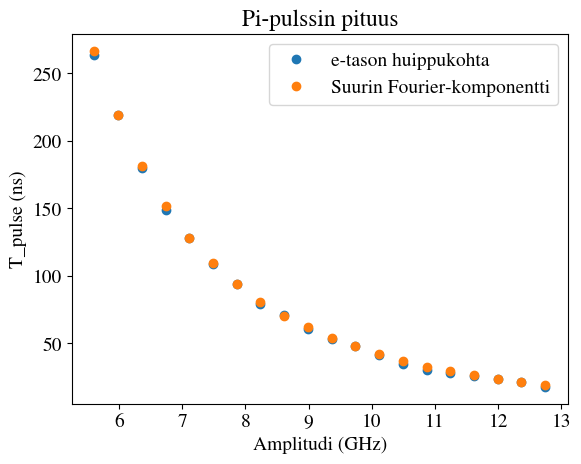

[np.float64(263.71667984955667), np.float64(219.24452504825143), np.float64(179.91589675752974), np.float64(148.73249500485733), np.float64(127.9643094376893), np.float64(108.650108992552), np.float64(93.7931596728207), np.float64(78.89944381594209), np.float64(70.74266179118288), np.float64(61.06314032871375), np.float64(53.61054731991714), np.float64(48.411897165542186), np.float64(41.68121138282748), np.float64(34.923191665812986), np.float64(30.42572456885395), np.float64(28.209566937730845), np.float64(25.982255045299972), np.float64(23.74391024174503), np.float64(21.49413175128607), np.float64(17.69325307935983)]


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Amplitudi (GHz)')

Text(0, 0.5, 'Rabi-taajuus (GHz)')

Text(0.5, 1.0, 'Rabi taajuus')

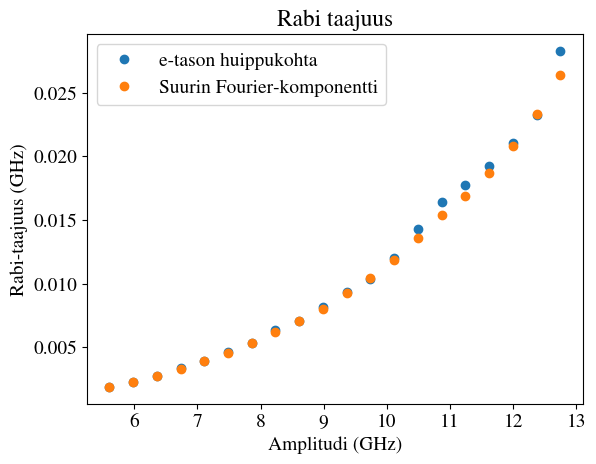

[np.float64(0.0018754674743472353), np.float64(0.0022782773397321053), np.float64(0.002754827400526749), np.float64(0.003294534851320295), np.float64(0.003900496516964254), np.float64(0.004553396694524399), np.float64(0.005313917561880334), np.float64(0.006214372450408386), np.float64(0.007077758152185239), np.float64(0.00801705764506023), np.float64(0.009224812470731087), np.float64(0.010465130350019159), np.float64(0.011828540296440163), np.float64(0.01359301166788543), np.float64(0.01541345436754027), np.float64(0.016915292355113385), np.float64(0.018691380187685458), np.float64(0.02080717881722879), np.float64(0.023328816932856315), np.float64(0.026349943344227834)]


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Amplitudi (GHz)')

Text(0, 0.5, 'P')

Text(0.5, 1.0, 'Tasojen suurimmat todennäköisyydet')

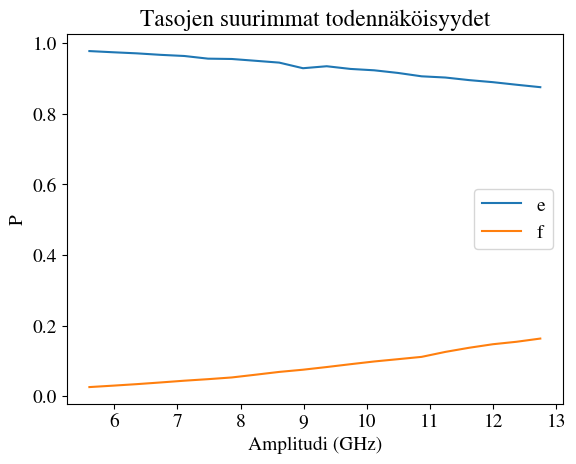

[np.float64(0.9781110907557555), np.float64(0.9747556165205028), np.float64(0.9716769277174403), np.float64(0.9674442396269434), np.float64(0.9641896175379903), np.float64(0.9566466548337951), np.float64(0.9556982879022466), np.float64(0.950594948222615), np.float64(0.9454137211959094), np.float64(0.9295243584165793), np.float64(0.9351464055978024), np.float64(0.9275189676207868), np.float64(0.9236257880535614), np.float64(0.9161880983568231), np.float64(0.9065860600360053), np.float64(0.9031516763456788), np.float64(0.8958293941663837), np.float64(0.890009023154285), np.float64(0.8827035259213989), np.float64(0.8758023931579968)]
[np.float64(0.02585028170639652), np.float64(0.029900544695255268), np.float64(0.03419222916680657), np.float64(0.03895363901101014), np.float64(0.04392667481676336), np.float64(0.04827914237641661), np.float64(0.053134276919580774), np.float64(0.06088085858549977), np.float64(0.0688436845555687), np.float64(0.07507052576688895), np.float64(0.0826490913503967

In [9]:
print(A_vals)

plt.figure()
plt.plot(A_vals, deltas, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("delta=ω_d-ω_q/3 (GHz)")
plt.title("AC stark siirtymä")
plt.show()
print(deltas)

plt.figure()
plt.plot(A_vals, pulse_lengths, 'o')
plt.plot(A_vals, 1/(2*np.array(rabis)), 'o')
plt.legend(["e-tason huippukohta","Suurin Fourier-komponentti"])
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("T_pulse (ns)")
plt.title("Pi-pulssin pituus")
plt.show()
print(pulse_lengths)

plt.figure()
plt.plot(A_vals, 1/(2*np.array(pulse_lengths)), 'o')
plt.plot(A_vals, rabis, 'o')
plt.legend(["e-tason huippukohta","Suurin Fourier-komponentti"])
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("Rabi-taajuus (GHz)")
plt.title("Rabi taajuus")
plt.show()
print(rabis)

e_vals=[arr[0] for arr in max_vals]
f_vals=[arr[1] for arr in max_vals]

plt.figure()
plt.plot(A_vals, e_vals)
plt.plot(A_vals, f_vals)
plt.legend(["e","f"])
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()
print(e_vals)
print(f_vals)

[-0.11529089000000001, -0.11519088999999999, -0.11509089, -0.11499089, -0.11489089, -0.11479089, -0.11469088999999999, -0.11459089, -0.11449089, -0.11439089, -0.11429089, -0.11419088999999999, -0.11409089, -0.11399089, -0.11389089, -0.11379089, -0.11369088999999999, -0.11359089, -0.11349089, -0.11339089, -0.11329089, -0.11319089, -0.11309089, -0.11299089, -0.11289089, -0.11279089, -0.11269089, -0.11259089, -0.11249089, -0.11239089, -0.11229089, -0.11219089, -0.11209089, -0.11199089000000001, -0.11189088999999999, -0.11179089, -0.11169089, -0.11159089, -0.11149089000000001, -0.11139088999999999, -0.11129089, -0.11119089, -0.11109089, -0.11099089000000001, -0.11089088999999999, -0.11079089, -0.11069089, -0.11059089, -0.11049089000000001, -0.11039088999999999, -0.11029089, -0.11019089, -0.11009089, -0.10999089000000001, -0.10989088999999999, -0.10979089, -0.10969089, -0.10959089, -0.10949089000000001, -0.10939088999999999, -0.10929089, -0.10919089, -0.10909089, -0.10899089, -0.10889088999

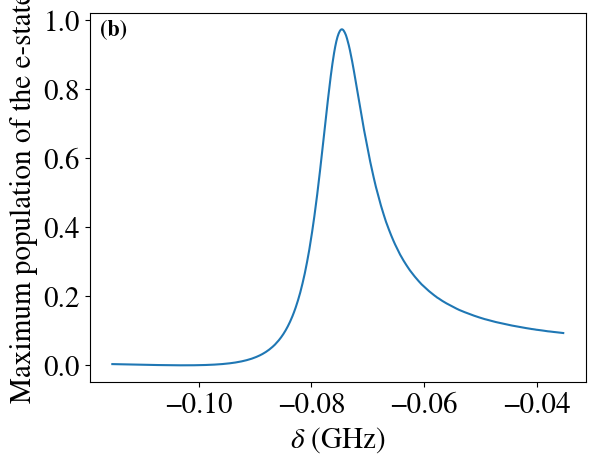

'else:\n    vals=sim_pulse_NF(f_d_opt,A,evolution_eigenbasis,dim,f_rabi/m)\n    freqs = np.fft.rfftfreq(len(vals[4]), d=vals[4][1]-vals[4][0]) '

Rabi-taajuus (fourier):  0.002485268474919258


Text(0.5, 0, 'Pulse duration (ns)')

Text(0.02, 0.92, '(b)')

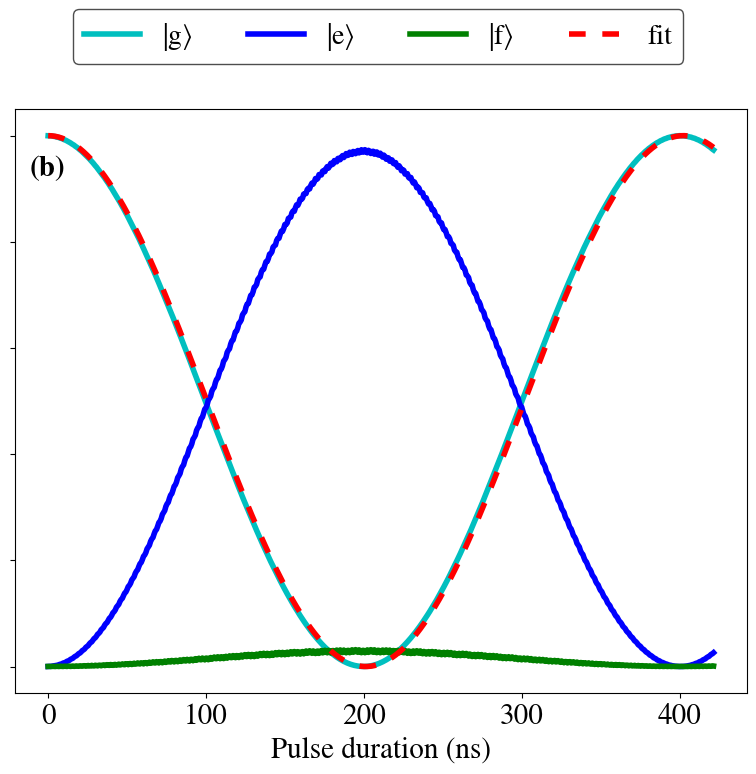

In [28]:
A = 6.15

f_rabi=2.875e-05*A**3 - 0.0003995*A**2 + 0.003097*A - 0.008257 #Arvaus Rabi-taajuudelle
AC_stark=-0.002324*A**2 + 0.005164 *A - 0.01915 #Arvaus AC-stark siirtymälle
params=find_params(qubit, A, evolution_eigenbasis,f_rabi,AC_stark)
f_d_opt = qubit.frequency/3+params[0] #Löydetty optimaalinen ajotaajuus

m=100
T_floquet = 2*np.pi/(f_d_opt)

vals=sim_pulse(f_d_opt,A,evolution_eigenbasis,dim,f_rabi/m)
freqs = np.fft.rfftfreq(len(vals[4]), d=T_floquet) 
"""else:
    vals=sim_pulse_NF(f_d_opt,A,evolution_eigenbasis,dim,f_rabi/m)
    freqs = np.fft.rfftfreq(len(vals[4]), d=vals[4][1]-vals[4][0]) """

g_vals=np.array([np.abs(arr[0])**2 for arr in vals[3]])
e_vals=np.array([np.abs(arr[1])**2 for arr in vals[3]])
f_vals=np.array([np.abs(arr[2])**2 for arr in vals[3]])

g_vals_offset = g_vals-0.5 #Siirretään g-tason todennäköisyyksiä puolella alaspäin, dc-komponentin minimoinniksi
fft_vals = np.fft.rfft(g_vals_offset) #Fourier-muunnos

magnitude = np.abs(fft_vals) #Taajuuskomponentit
magnitude[0] = 0 #Hylätään nollataajuus/vakiokomponentti

frequency=freqs[np.argmax(magnitude)] #Suurin g-tason aikakehityksen taajuuskomponentti=Rabi-taajuus
print("Rabi-taajuus (fourier): ",frequency)

n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä

plot_vals= 0.5*(1+np.cos(2*np.pi*frequency*vals[4][:n_picked])) #Sovite Rabi-taajuudella

fig = plt.figure(figsize=(8, 8))

l1, = plt.plot(vals[4][:n_picked], g_vals[:n_picked], linewidth=4, color='c')
l2, = plt.plot(vals[4][:n_picked], e_vals[:n_picked], linewidth=4, color='b')
l3, = plt.plot(vals[4][:n_picked], f_vals[:n_picked], linewidth=4, color='g')
l4, = plt.plot(vals[4][:n_picked], plot_vals, ls='--', dashes=(3, 3), linewidth=4, color='r')

plt.xlabel("Pulse duration (ns)")

plt.legend(
    [l1, l2, l3, l4],
    [r"|$\mathrm{g}\rangle$", r"|$\mathrm{e}\rangle$", r"|$\mathrm{f}\rangle$", "fit"],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.0),
    bbox_transform=fig.transFigure,
    ncol=4,
    fontsize=20,
    frameon=True,
    facecolor="white",
    edgecolor="0.3",
    framealpha=1.0
)

ax = plt.gca()

ax.tick_params(axis='y', which='both', left=True, labelleft=False)

ax.text(0.02, 0.92, "(b)",
        transform=ax.transAxes,
        va="top",
        fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig("resonanssi-sub.pdf", bbox_inches="tight")
plt.show()